<a href="https://colab.research.google.com/github/rabyaibtesam-lgtm/Machine-learning/blob/main/credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d

In [3]:


dataset=pd.read_csv("credit.csv")



In [4]:

dataset.head()



,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:


dataset.drop(columns=["CUST_ID"],inplace=True)

dataset.head()



,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:


dataset.shape



(8950, 17)

In [7]:
# Check missing values count per column
print(dataset.isnull().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [8]:


dataset["MINIMUM_PAYMENTS"] = dataset["MINIMUM_PAYMENTS"].fillna(dataset["MINIMUM_PAYMENTS"].mean())
dataset["CREDIT_LIMIT"] = dataset["CREDIT_LIMIT"].fillna(dataset["CREDIT_LIMIT"].mean())



In [9]:
# Check missing values count per column
print(dataset.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [10]:


dataset.columns



Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [12]:


kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(dataset)



In [13]:


y_kmeans



array([1, 0, 0, ..., 1, 1, 1], dtype=int32)

In [14]:


# Step 3: Add cluster labels to data
dataset['Cluster'] = y_kmeans



In [15]:
dataset['Cluster']

,Cluster
0,1
1,0
2,0
3,0
4,1
...,...
8945,1
8946,1
8947,1
8948,1


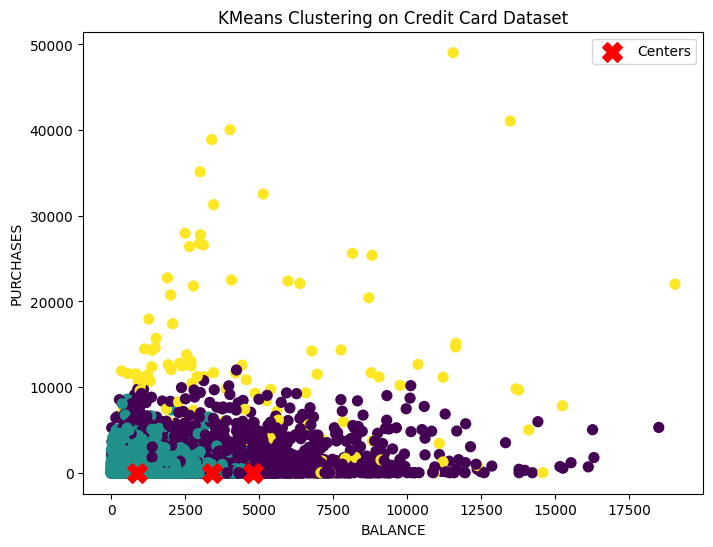

In [16]:
# Step 4: Visualize clusters using 2D (first two features)
plt.figure(figsize=(8,6))
plt.scatter(dataset.iloc[:,0], dataset.iloc[:,2], c=dataset['Cluster'], cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label="Centers")

plt.xlabel(dataset.columns[0])
plt.ylabel(dataset.columns[2])
plt.title("KMeans Clustering on Credit Card Dataset")
plt.legend()
plt.show()

In [17]:


# Taking Prediction on one sample, belongs to which cluster
# 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
    #    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    #    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    #    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    #    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
    #    'TENURE'
sample = [[2000, 0.8, 1500, 200, 300, 100, 0.5, 0.1, 0.3, 0.2, 2, 15, 5000, 1000, 150, 0.1, 12]]
predicted_cluster = kmeans.predict(sample)
print(f"The sample belongs to cluster: {predicted_cluster[0]}")




The sample belongs to cluster: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [18]:
# Whats the Average Balance of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]

print("Average Balance of Cluster 0:", cluster1['BALANCE'].mean())
print("Average Balance of Cluster 1:", cluster2['BALANCE'].mean())
print("Average Balance of Cluster 2:", cluster3['BALANCE'].mean())

Average Balance of Cluster 0: 3395.8739855109075
Average Balance of Cluster 1: 854.6721726106682
Average Balance of Cluster 2: 4797.203573253732


In [19]:
# Whats the Average Credit Limit of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]

print("Average Credit Limit of Cluster 0:", cluster1['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 1:", cluster2['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 2:", cluster3['CREDIT_LIMIT'].mean())


Average Credit Limit of Cluster 0: 8998.213152467279
Average Credit Limit of Cluster 1: 2748.3703303660886
Average Credit Limit of Cluster 2: 12470.522388059702


In [20]:


from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate clustering metrics
silhouette = silhouette_score(dataset, kmeans.labels_)
db_index = davies_bouldin_score(dataset, kmeans.labels_)
ch_index = calinski_harabasz_score(dataset, kmeans.labels_)

# Print the metric scores
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")



Silhouette Score: 0.47
Davies-Bouldin Index: 1.20
Calinski-Harabasz Index: 3079.39


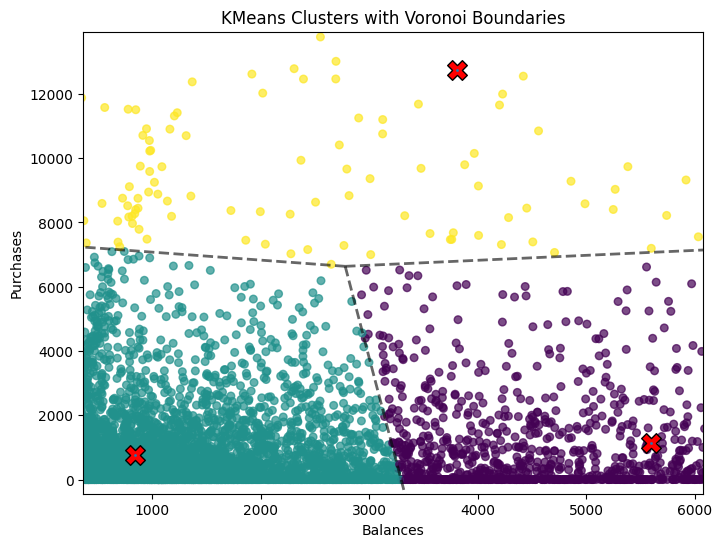

In [22]:

# Take only first 2 columns for visualization
X_2d = dataset[["BALANCE", "PURCHASES"]].values

# Fit KMeans again on 2D data
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_2d)
centers = kmeans.cluster_centers_

# Plot scatter
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_kmeans, cmap="viridis", s=30, alpha=0.7)

# Add Voronoi polygons
vor = Voronoi(centers)
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='black', line_width=2, line_alpha=0.6, point_size=2)

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="X", edgecolors="black")

plt.xlabel("Balances")
plt.ylabel("Purchases")
plt.title("KMeans Clusters with Voronoi Boundaries")
plt.show()



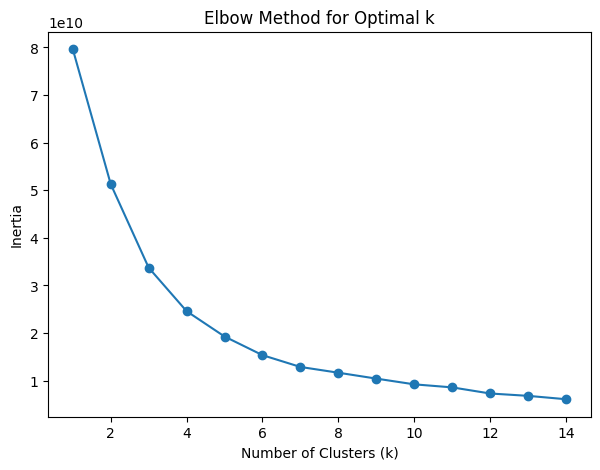

In [23]:
inertia = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42).fit(X_2d)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

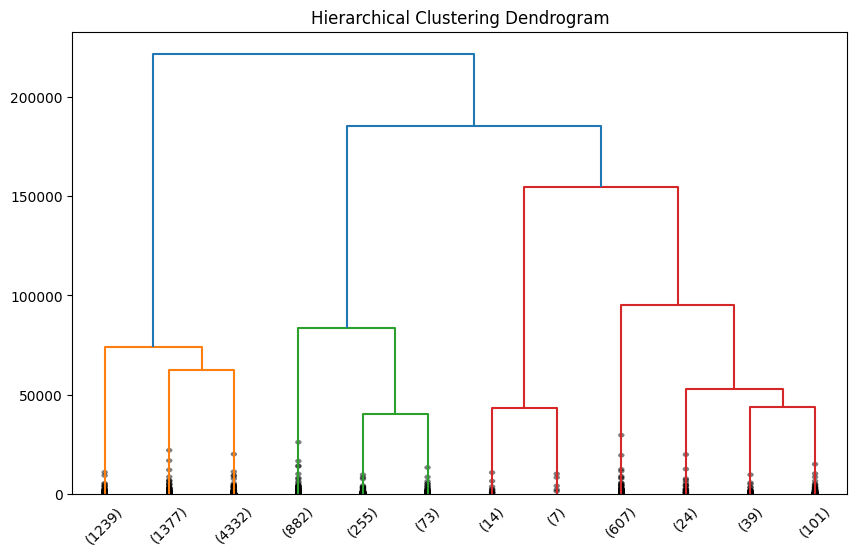

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_2d, 'ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode="lastp", p=12, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()
